<a href="https://colab.research.google.com/github/usama488/bioinformatics-analysis/blob/main/AI_Cancer_Prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#  **AI-based Cancer Prediction – Intelligent Breast Cancer Diagnosis**

## Welcome to AI-based Cancer Prediction, a machine learning project developed to predict whether a breast tumor is malignant or benign using the Breast Cancer Wisconsin (Diagnostic) dataset. This project demonstrates how artificial intelligence can assist healthcare professionals by providing fast, accurate, and data-driven predictions to support early cancer detection.




## **Project Pipeline**

-  **Load & Explore Data** – Import and analyze the Breast Cancer Wisconsin (Diagnostic) dataset.
-  **Data Preprocessing** – Handle feature scaling and split the dataset into training and testing sets.
-  **Model Training** – Train multiple machine learning models, including:
  - Logistic Regression
  - Random Forest
  - Support Vector Machine (SVM)
  - Gradient Boosting
-  **Model Evaluation** – Compare model performance using:
  - Accuracy
  - Precision
  - Recall
  - ROC-AUC Score
  - Confusion Matrix
-  **Feature Importance Analysis** – Identify the most influential features contributing to predictions.
-  **Model Saving** – Save the best-performing model for future inference and deployment.


## 1. Setup & Imports

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, roc_curve, confusion_matrix, classification_report
)
import joblib
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (8, 5)
np.random.seed(42)

## 2. Load Dataset

In [ ]:
data = load_breast_cancer()
df = pd.DataFrame(data.data, columns=data.feature_names)
df['target'] = data.target
df['diagnosis'] = df['target'].map({0: 'malignant', 1: 'benign'})

print(f"Shape: {df.shape}")
df.head()


Shape: (569, 32)


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target,diagnosis
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,0,malignant
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,0,malignant
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,0,malignant
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,0,malignant
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,0,malignant


In [ ]:
pd.read_csv('your_file.csv')

## 3. Exploratory Data Analysis

In [ ]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 32 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   mean radius              569 non-null    float64
 1   mean texture             569 non-null    float64
 2   mean perimeter           569 non-null    float64
 3   mean area                569 non-null    float64
 4   mean smoothness          569 non-null    float64
 5   mean compactness         569 non-null    float64
 6   mean concavity           569 non-null    float64
 7   mean concave points      569 non-null    float64
 8   mean symmetry            569 non-null    float64
 9   mean fractal dimension   569 non-null    float64
 10  radius error             569 non-null    float64
 11  texture error            569 non-null    float64
 12  perimeter error          569 non-null    float64
 13  area error               569 non-null    float64
 14  smoothness error         5

In [ ]:
print("Missing values:\n", df.isnull().sum().sum())
print("\nClass distribution:")
print(df['diagnosis'].value_counts())
fig = px.histogram(df, x='diagnosis', color='diagnosis',
                   title='Class Distribution: Malignant vs Benign',
                   labels={'diagnosis': 'Diagnosis', 'count': 'Count'},
                   category_orders={'diagnosis': ['malignant', 'benign']})
fig.update_layout(bargap=0.2)
fig.show()

Missing values:
 0

Class distribution:
diagnosis
benign       357
malignant    212
Name: count, dtype: int64


In [ ]:
df.describe().T


,count,mean,std,min,25%,50%,75%,max
mean radius,569.0,14.127292,3.524049,6.981000,11.700000,13.370000,15.780000,28.11000
mean texture,569.0,19.289649,4.301036,9.710000,16.170000,18.840000,21.800000,39.28000
mean perimeter,569.0,91.969033,24.298981,43.790000,75.170000,86.240000,104.100000,188.50000
mean area,569.0,654.889104,351.914129,143.500000,420.300000,551.100000,782.700000,2501.00000
mean smoothness,569.0,0.096360,0.014064,0.052630,0.086370,0.095870,0.105300,0.16340
mean compactness,569.0,0.104341,0.052813,0.019380,0.064920,0.092630,0.130400,0.34540
mean concavity,569.0,0.088799,0.079720,0.000000,0.029560,0.061540,0.130700,0.42680
mean concave points,569.0,0.048919,0.038803,0.000000,0.020310,0.033500,0.074000,0.20120
mean symmetry,569.0,0.181162,0.027414,0.106000,0.161900,0.179200,0.195700,0.30400
mean fractal dimension,569.0,0.062798,0.007060,0.049960,0.057700,0.061540,0.066120,0.09744


# Correlation heatmap of top features with target

In [17]:
top_corr_df = top_corr.drop('target', errors='ignore').reset_index()
top_corr_df.columns = ['Feature', 'Correlation']

fig = px.bar(top_corr_df, y='Feature', x='Correlation',
             orientation='h',
             title='Top Features Correlated with Target',
             color='Correlation',
             color_continuous_scale=px.colors.sequential.Plasma,
             labels={'Correlation': 'Correlation with target'})
fig.update_layout(yaxis={'categoryorder':'total ascending'})
fig.show()

In [ ]:
corr_matrix = df.drop(columns=['diagnosis']).corr()

fig = px.imshow(corr_matrix, text_auto=True,
                color_continuous_scale='RdBu',
                title='Feature Correlation Matrix',
                aspect="auto")
fig.update_layout(xaxis_showgrid=False, yaxis_showgrid=False)
fig.show()

## 4. Preprocessing

In [18]:
X = df[data.feature_names]
y = df['target']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"Train shape: {X_train.shape}, Test shape: {X_test.shape}")


Train shape: (455, 30), Test shape: (114, 30)


## 5. Train Multiple Models

In [19]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=5000, random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=300, random_state=42),
    "SVM (RBF)": SVC(probability=True, random_state=42),
    "Gradient Boosting": GradientBoostingClassifier(random_state=42),
}

results = []

for name, model in models.items():
    model.fit(X_train_scaled, y_train)
    preds = model.predict(X_test_scaled)
    probs = model.predict_proba(X_test_scaled)[:, 1]

    results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, preds),
        "Precision": precision_score(y_test, preds),
        "Recall": recall_score(y_test, preds),
        "F1": f1_score(y_test, preds),
        "ROC-AUC": roc_auc_score(y_test, probs),
    })

results_df = pd.DataFrame(results).sort_values("ROC-AUC", ascending=False).reset_index(drop=True)
results_df


,Model,Accuracy,Precision,Recall,F1,ROC-AUC
0,Logistic Regression,0.982456,0.986111,0.986111,0.986111,0.995370
1,SVM (RBF),0.982456,0.986111,0.986111,0.986111,0.995040
2,Random Forest,0.947368,0.958333,0.958333,0.958333,0.993717
3,Gradient Boosting,0.956140,0.946667,0.986111,0.965986,0.990741


## 6. Model Comparison

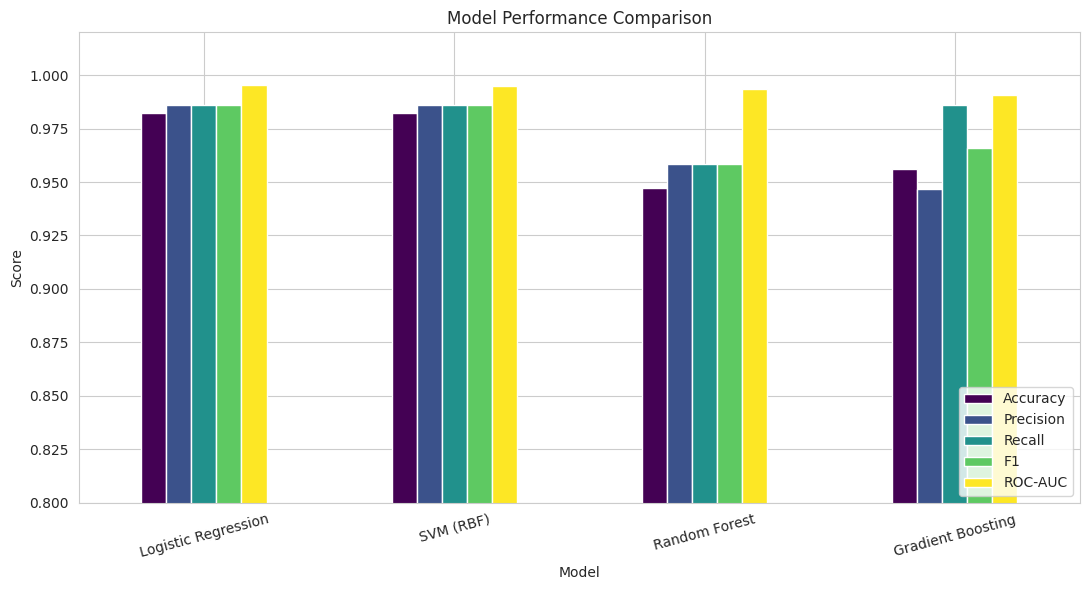

In [20]:
results_df.set_index("Model")[["Accuracy", "Precision", "Recall", "F1", "ROC-AUC"]].plot(
    kind='bar', figsize=(11, 6), colormap='viridis'
)
plt.title("Model Performance Comparison")
plt.ylabel("Score")
plt.ylim(0.8, 1.02)
plt.legend(loc='lower right')
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()


## 7. Best Model — Detailed Evaluation

In [21]:
best_model_name = results_df.iloc[0]["Model"]
best_model = models[best_model_name]
print(f"Best model: {best_model_name}")

preds = best_model.predict(X_test_scaled)
probs = best_model.predict_proba(X_test_scaled)[:, 1]

print("\nClassification Report:\n")
print(classification_report(y_test, preds, target_names=['malignant', 'benign']))


Best model: Logistic Regression

Classification Report:

              precision    recall  f1-score   support

   malignant       0.98      0.98      0.98        42
      benign       0.99      0.99      0.99        72

    accuracy                           0.98       114
   macro avg       0.98      0.98      0.98       114
weighted avg       0.98      0.98      0.98       114



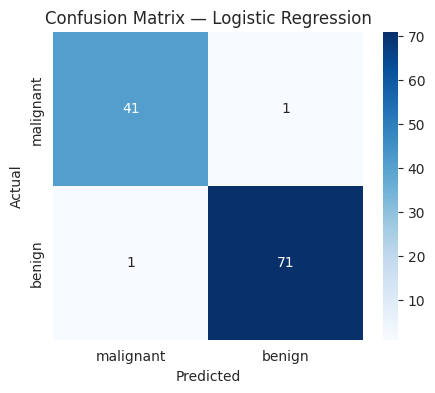

In [22]:
cm = confusion_matrix(y_test, preds)
plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['malignant', 'benign'],
            yticklabels=['malignant', 'benign'])
plt.title(f"Confusion Matrix — {best_model_name}")
plt.ylabel("Actual")
plt.xlabel("Predicted")
plt.show()


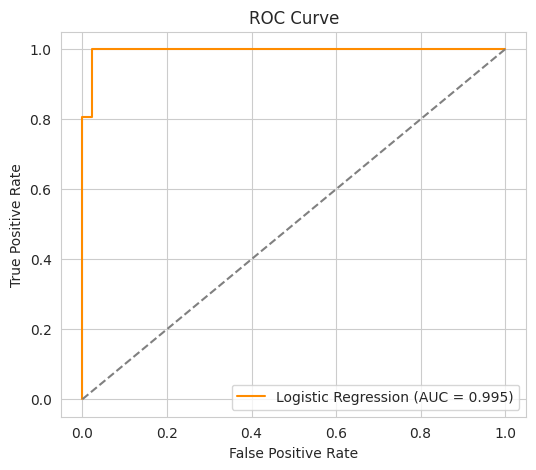

In [23]:
fpr, tpr, _ = roc_curve(y_test, probs)
auc = roc_auc_score(y_test, probs)

plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, label=f"{best_model_name} (AUC = {auc:.3f})", color='darkorange')
plt.plot([0, 1], [0, 1], linestyle='--', color='gray')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend(loc='lower right')
plt.show()


## 8. Feature Importance

In [24]:
if hasattr(best_model, "feature_importances_"):
    importances = pd.Series(best_model.feature_importances_, index=data.feature_names)
    importances = importances.sort_values(ascending=False).head(15)

    plt.figure(figsize=(9, 6))
    importances.sort_values().plot(kind='barh', color='seagreen')
    plt.title(f"Top 15 Feature Importances — {best_model_name}")
    plt.tight_layout()
    plt.show()
else:
    print(f"{best_model_name} does not expose feature_importances_ directly. "
          "Consider permutation importance for a model-agnostic view.")


Logistic Regression does not expose feature_importances_ directly. Consider permutation importance for a model-agnostic view.


## 9. Cross-Validation Sanity Check

In [28]:
cv_scores = cross_val_score(best_model, scaler.fit_transform(X), y, cv=5, scoring='roc_auc')
print(f"5-fold CV ROC-AUC: {cv_scores.mean():.4f} ± {cv_scores.std():.4f}")
print("Fold scores:", np.round(cv_scores, 4))


5-fold CV ROC-AUC: 0.9953 ± 0.0040
Fold scores: [0.9954 0.9967 0.997  0.9878 0.9997]


## 10. Save the Model

In [29]:
joblib.dump(best_model, "cancer_prediction_model.joblib")
joblib.dump(scaler, "cancer_prediction_scaler.joblib")
print("Saved: cancer_prediction_model.joblib, cancer_prediction_scaler.joblib")


Saved: cancer_prediction_model.joblib, cancer_prediction_scaler.joblib


## 11. Predict on a New Sample (Demo)

Example of loading the saved model and scaler to predict on a single new patient record.


In [30]:
# Demo: take one test-set sample and predict as if it were new incoming data
sample = X_test.iloc[[0]]
sample_scaled = scaler.transform(sample)

loaded_model = joblib.load("cancer_prediction_model.joblib")
pred = loaded_model.predict(sample_scaled)[0]
prob = loaded_model.predict_proba(sample_scaled)[0][1]

label = "benign" if pred == 1 else "malignant"
print(f"Prediction: {label}  (P(benign) = {prob:.3f})")
print(f"Actual: {'benign' if y_test.iloc[0] == 1 else 'malignant'}")


Prediction: malignant  (P(benign) = 0.000)
Actual: malignant
